# Distributional Regression Illustration

This notebook builds a synthetic data-generating process with a known conditional PDF, fits `DistributionalRegressionPDF`, and compares the fitted conditional densities against the true conditional densities. The design is intentionally asymmetric and right-skewed so the comparison is economically meaningful for the intended use case.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.integrate import trapezoid

from distributional_regression_pdf import DistributionalRegressionPDF

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(12345)


In [2]:
def simulate_conditional_lognormal(n, rng):
    X = rng.normal(size=(n, 2))
    x0 = X[:, 0]
    x1 = X[:, 1]
    loc = 0.60 * np.sin(0.9 * x0) - 0.30 * x1
    mu = 0.20 * x0 - 0.10 * x1
    sigma = 0.35 + 0.12 * np.abs(x1)
    y = loc + rng.lognormal(mean=mu, sigma=sigma)
    params = {
        'loc': loc,
        'mu': mu,
        'sigma': sigma,
    }
    return y, X, params


def true_pdf(y_grid, x_row):
    x0, x1 = x_row
    loc = 0.60 * np.sin(0.9 * x0) - 0.30 * x1
    mu = 0.20 * x0 - 0.10 * x1
    sigma = 0.35 + 0.12 * abs(x1)
    shifted = y_grid - loc
    density = np.zeros_like(y_grid, dtype=float)
    mask = shifted > 0.0
    density[mask] = lognorm.pdf(shifted[mask], s=sigma, scale=np.exp(mu))
    return density


In [5]:
y_train, X_train, _ = simulate_conditional_lognormal(2500, rng)
y_test, X_test, _ = simulate_conditional_lognormal(600, rng)

model = DistributionalRegressionPDF(
    basis='chebyshev',
    degree_y=5,
    degree_x=4,
    include_interactions=True,
    x_interaction_order=1,
    n_integration_nodes=64,
)
model.fit(y_train, X_train, l1_alpha=1e-4, l2_alpha=1e-3, cv=True, folds=3, rng=123)
print(model.summary())


DistributionalRegressionPDF Summary
-----------------------------------
Basis: chebyshev
degree_y=5, degree_x=4
include_interactions=True, x_interaction_order=1
n_samples=2500, n_features=2
n_active_features=2, n_constant_features=0
y_domain=(-1.274663033842332, 9.162396058544815)
standardize_X=True, standardize_y=True
fit_intercept_requested=True, fit_intercept_identifiable=False
n_parameters=45
selected_l1_alpha=0, selected_l2_alpha=1e-05
optimizer=L-BFGS-B, success=True
optimizer_message=CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
objective_value=0.651080
gradient_norm=0.000420
mean_loglik=-0.648778
cv_used=True
cv_selected=(l1=0, l2=1e-05, mean_valid_loglik=-0.686754)


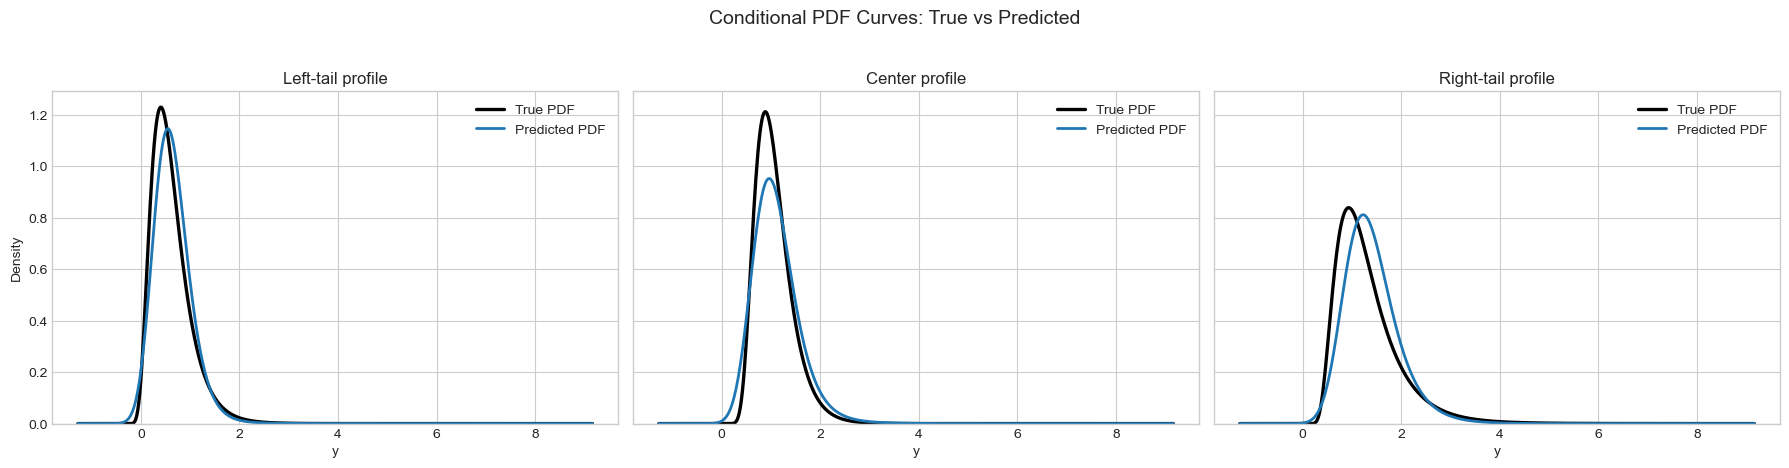

In [6]:
profiles = np.array([
    [-1.0, -0.5],
    [0.0, 0.0],
    [1.0, 1.25],
])
labels = ['Left-tail profile', 'Center profile', 'Right-tail profile']
grid = np.linspace(model.y_domain_[0], model.y_domain_[1], 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, x_row, label in zip(axes, profiles, labels):
    predicted = np.asarray(model.pdf(grid, x_row), dtype=float)
    actual = true_pdf(grid, x_row)
    ax.plot(grid, actual, label='True PDF', linewidth=2.4, color='black')
    ax.plot(grid, predicted, label='Predicted PDF', linewidth=2.0, color='tab:blue')
    ax.set_title(label)
    ax.set_xlabel('y')
    ax.set_ylim(bottom=0.0)
    ax.legend()
axes[0].set_ylabel('Density')
fig.suptitle('Conditional PDF Curves: True vs Predicted', y=1.03, fontsize=14)
fig.tight_layout()


In [7]:
rows = []
for x_row in X_test[:80]:
    predicted = np.asarray(model.pdf(grid, x_row), dtype=float)
    actual = true_pdf(grid, x_row)
    ise = trapezoid((predicted - actual) ** 2, grid)
    l1_error = trapezoid(np.abs(predicted - actual), grid)
    rows.append((ise, l1_error))

errors = np.asarray(rows)
print(f'Mean integrated squared error: {errors[:, 0].mean():.6f}')
print(f'Mean integrated absolute error: {errors[:, 1].mean():.6f}')


Mean integrated squared error: 0.032196
Mean integrated absolute error: 0.201421


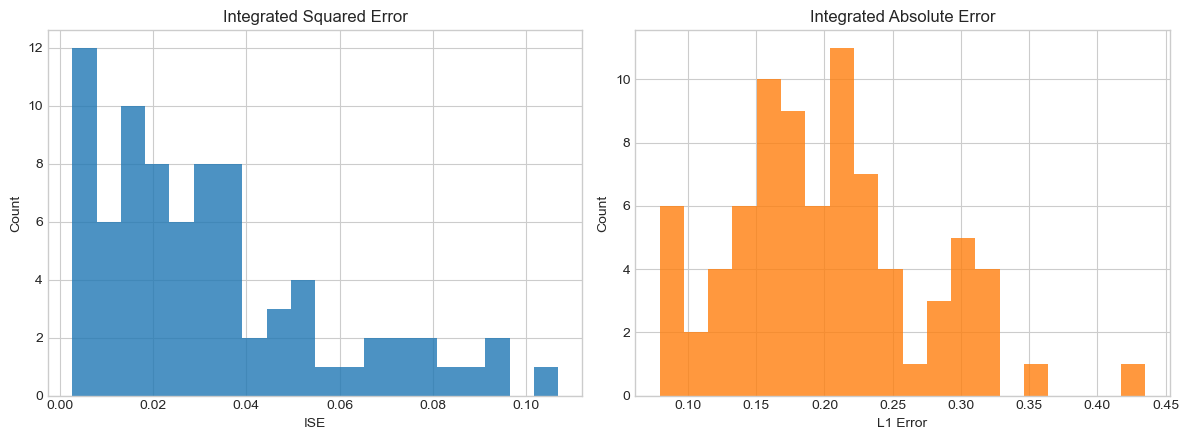

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(errors[:, 0], bins=20, color='tab:blue', alpha=0.8)
axes[0].set_title('Integrated Squared Error')
axes[0].set_xlabel('ISE')
axes[0].set_ylabel('Count')

axes[1].hist(errors[:, 1], bins=20, color='tab:orange', alpha=0.8)
axes[1].set_title('Integrated Absolute Error')
axes[1].set_xlabel('L1 Error')
axes[1].set_ylabel('Count')

fig.tight_layout()


In [9]:
test_log_score = np.mean(model.logpdf(y_test, X_test))
true_log_score = np.mean(np.log(np.maximum([true_pdf(np.array([yy]), xx)[0] for yy, xx in zip(y_test, X_test)], 1e-300)))
print(f'Mean fitted log score on held-out data: {test_log_score:.6f}')
print(f'Mean true log score on held-out data:   {true_log_score:.6f}')
print(f'Gap (true - fitted): {true_log_score - test_log_score:.6f}')


Mean fitted log score on held-out data: -0.729186
Mean true log score on held-out data:   -0.645707
Gap (true - fitted): 0.083478
